# 02 — Event study

**Events:**

| Date | Event | Role |
|------|-------|------|
| 2019-09-16 | Aramco Abqaiq drone strike | historical comparable |
| 2020-01-03 | Soleimani assassination | historical comparable (window censored pre-COVID) |
| 2024-01-19 | Houthi Red Sea escalation | ambient-escalation control |
| 2026-02-28 | Operation Epic Fury (conflict start) | **primary focal event, t=0** |
| 2026-03-04 | Strait of Hormuz closure | secondary anchor (supply-shock trigger) |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

# Locate repo root regardless of whether notebook is run from repo/ or notebooks/
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Load the Brent–WTI dollar spread built in 01_cointegration.ipynb
df = pd.read_csv(REPO / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date")
df = df.sort_index()

# ── Event catalogue ──────────────────────────────────────────────────────────
# Three historical comparables + two 2026 focal events.
# Dates are the *announcement* date (first trading day on/after is found below).
EVENTS = {
    "Aramco 2019":   "2019-09-16",   # Abqaiq drone strike — largest physical disruption of the era
    "Soleimani 2020": "2020-01-03",  # Assassination — geopolitical/sentiment shock
    "Houthi 2024":   "2024-01-19",   # Red Sea escalation — ambient, low-intensity
    "Epic Fury 2026": "2026-02-28",  # Primary focal event (conflict start)
    "Hormuz 2026":   "2026-03-04",   # Secondary focal event (Strait closure — supply-shock trigger)
}

# ── Censoring ────────────────────────────────────────────────────────────────
# Some event windows overlap an *unrelated* later shock that would distort metrics.
# Any data on/after the censor date is masked for that event only.
# Soleimani: the COVID oil crash begins ~Feb 2020; without censoring, the March
# crash would appear as a ~−16σ Soleimani-attributed move (it isn't).
CENSOR = {
    "Soleimani 2020": "2020-02-21",
}

# ── Window parameters (all in trading days) ───────────────────────────────────
PRE_LEN      = 60   # Estimation window length: 60 days of pre-event data for μ/σ
PRE_GAP      = 20   # Gap between estimation window end and event day.
                    # Keeps any pre-event run-up *visible* in the z-path rather
                    # than absorbed into the baseline (standard event-study practice).
WIN_PRE      = 20   # Display window: start 20 days before event
WIN_POST     = 60   # Display window: end 60 days after event
PEAK_HORIZON = 20   # Metrics horizon: compute peak/renorm on [0, +20] only.
                    # Avoids attributing unrelated later moves (e.g. COVID crash)
                    # to the event when the full +60 window is shown.

print(f"data {df.index.min().date()} → {df.index.max().date()}; {len(EVENTS)} events")


data 1987-05-20 → 2026-06-01; 5 events


## Build spread-z paths on a common event-day axis

In [2]:
def event_pos(date_str: str) -> int:
    """Return the integer iloc of the first trading day on/after `date_str`.

    searchsorted finds the insertion point for the timestamp in the sorted
    DatetimeIndex — i.e. the first row whose date >= the event date.
    This handles weekends and holidays automatically.
    """
    return int(df.index.searchsorted(pd.Timestamp(date_str)))


# Build a common event-day axis: offsets run from −WIN_PRE to +WIN_POST.
# Each event's z-path is aligned so offset 0 = the event day.
offsets = np.arange(-WIN_PRE, WIN_POST + 1)
z_paths      = pd.DataFrame(index=offsets)   # standardised spread paths
spread_paths = pd.DataFrame(index=offsets)   # raw dollar spread paths (for vol metrics)
baselines    = {}                            # store μ/σ per event for inspection

for name, date_str in EVENTS.items():
    pos = event_pos(date_str)

    # ── Estimation window ────────────────────────────────────────────────────
    # [pos−80 : pos−20] — 60 trading days ending 20 days before the event.
    # Using ddof=1 (sample std) is standard; σ is used to normalise the z-path.
    est = df["spread"].iloc[pos - PRE_GAP - PRE_LEN : pos - PRE_GAP]
    mu, sigma = est.mean(), est.std(ddof=1)
    baselines[name] = {"baseline μ": mu, "baseline σ": sigma}

    # ── Extract and align the display window ─────────────────────────────────
    # Clip to valid data range with max/min to avoid index-out-of-bounds.
    lo, hi = max(pos - WIN_PRE, 0), min(pos + WIN_POST + 1, len(df))
    seg = df["spread"].iloc[lo:hi]

    # Convert absolute iloc positions to event-day offsets.
    rel = np.arange(lo, hi) - pos
    s = pd.Series(seg.values, index=rel)

    # ── Censor contaminated tail ──────────────────────────────────────────────
    # Drop everything on/after the censor date (expressed as an offset).
    if name in CENSOR:
        cutoff_off = event_pos(CENSOR[name]) - pos
        s = s[s.index < cutoff_off]

    # ── Align to common index; missing offsets become NaN ────────────────────
    # reindex pads with NaN for offsets that don't exist (truncated windows,
    # censor cuts, data end). This keeps all DataFrames the same shape.
    spread_paths[name] = s.reindex(offsets)
    z_paths[name]      = (s.reindex(offsets) - mu) / sigma   # z_t = (x_t − μ) / σ

pd.DataFrame(baselines).T.round(2)


,baseline μ,baseline σ
Aramco 2019,7.63,2.73
Soleimani 2020,6.07,0.72
Houthi 2024,5.05,0.91
Epic Fury 2026,4.87,1.47
Hormuz 2026,4.98,1.51


In [3]:
# Sanity check: how many of the 81 display-window days are actually populated?
# Full window = 81 days (−20 to +60 inclusive).
# Fewer days = censored tail (Soleimani) or data truncation (2026 windows).
coverage = z_paths.notna().sum().to_frame("days covered (of 81)")
coverage["last offset"] = [z_paths[c].last_valid_index() for c in z_paths.columns]
coverage


,days covered (of 81),last offset
Aramco 2019,81,60
Soleimani 2020,53,32
Houthi 2024,81,60
Epic Fury 2026,81,60
Hormuz 2026,80,59


## Per-event metrics

Peak spread-z and days-to-peak are measured on the clean `[0, +PEAK_HORIZON]` window. Days-to-renorm is the first offset after the peak where |z|<1 (searched across the full available, censored window). Pre/post volatility uses the dollar spread over the displayed window.

In [4]:
def event_metrics(name: str) -> dict:
    """Compute key event-study statistics for a single event.

    All metrics are computed on the *censored, aligned* z-path — i.e.
    the same series plotted in the money plot.
    """
    z = z_paths[name]

    # ── Peak z-score ─────────────────────────────────────────────────────────
    # Restrict to the clean [0, +PEAK_HORIZON] window so I don't accidentally
    # pick up COVID/unrelated moves that happen later in the +60 display window.
    post = z[(z.index >= 0) & (z.index <= PEAK_HORIZON)].dropna()
    peak_off = post.abs().idxmax()   # offset of the largest absolute deviation
    peak_z   = post.loc[peak_off]    # signed z (positive = spread widened)

    # ── Days to renormalise ───────────────────────────────────────────────────
    # Search the full available window (post-peak) for the first day where
    # the spread-z falls back inside ±1 (roughly "back to normal baseline").
    # Returns NaN if the spread is still elevated at the end of the window.
    after_peak = z[z.index > peak_off].dropna()
    renorm = after_peak[after_peak.abs() < 1]
    days_to_renorm = int(renorm.index[0]) if len(renorm) else np.nan

    # ── Dollar-spread volatility (pre vs post event) ──────────────────────────
    # Uses the *raw dollar spread* (not z), so the vol ratio is in a
    # currency-comparable unit ($-per-barrel).
    sp       = spread_paths[name]
    pre_vol  = sp[sp.index < 0].std(ddof=1)   # [−20, −1] display window
    post_vol = sp[sp.index >= 0].std(ddof=1)  # [0, +60] display window

    return {
        "peak |z|": round(abs(peak_z), 2),
        "peak z (signed)": round(peak_z, 2),      # sign: + = widening, − = narrowing
        "days to peak": int(peak_off),
        "days to renorm": days_to_renorm,          # NaN = not renormalised in window
        "pre vol ($)": round(pre_vol, 2),
        "post vol ($)": round(post_vol, 2),
        "vol ratio": round(post_vol / pre_vol, 2), # >1 = event raised spread volatility
    }


metrics = pd.DataFrame({n: event_metrics(n) for n in EVENTS}).T
metrics


,peak |z|,peak z (signed),days to peak,days to renorm,pre vol ($),post vol ($),vol ratio
Aramco 2019,0.88,-0.88,20.0,21.0,1.30,0.76,0.59
Soleimani 2020,2.95,-2.95,20.0,31.0,0.66,1.02,1.53
Houthi 2024,3.06,3.06,9.0,18.0,1.25,1.48,1.18
Epic Fury 2026,11.63,11.63,12.0,44.0,0.77,6.98,9.01
Hormuz 2026,12.50,12.50,19.0,42.0,0.89,7.10,7.94


**Read (the central finding).** Historical Middle East shocks barely moved the Brent–WTI spread: Aramco 2019 — the largest physical supply disruption of its era — shifted the spread by **less than one σ** within 20 days; Soleimani and Houthi produced only ~±3σ, mixed in sign. The 2026 episode is **categorically different**: a clean, sustained widening of ~+12σ with post-event volatility 8–9× the pre-event baseline. The historical comparables function as the null that makes 2026 stand out — supporting a *structural-break* reading rather than "another transient blow-out."

## The money plot

Every event's spread-z path on one event-day axis, with the cross-event median and IQR band (2026 paths drawn bold on top). This figure is the visual core of the paper: it shows that supply shocks did *not* historically produce a large characteristic spread response — and that 2026 departs sharply from that history.

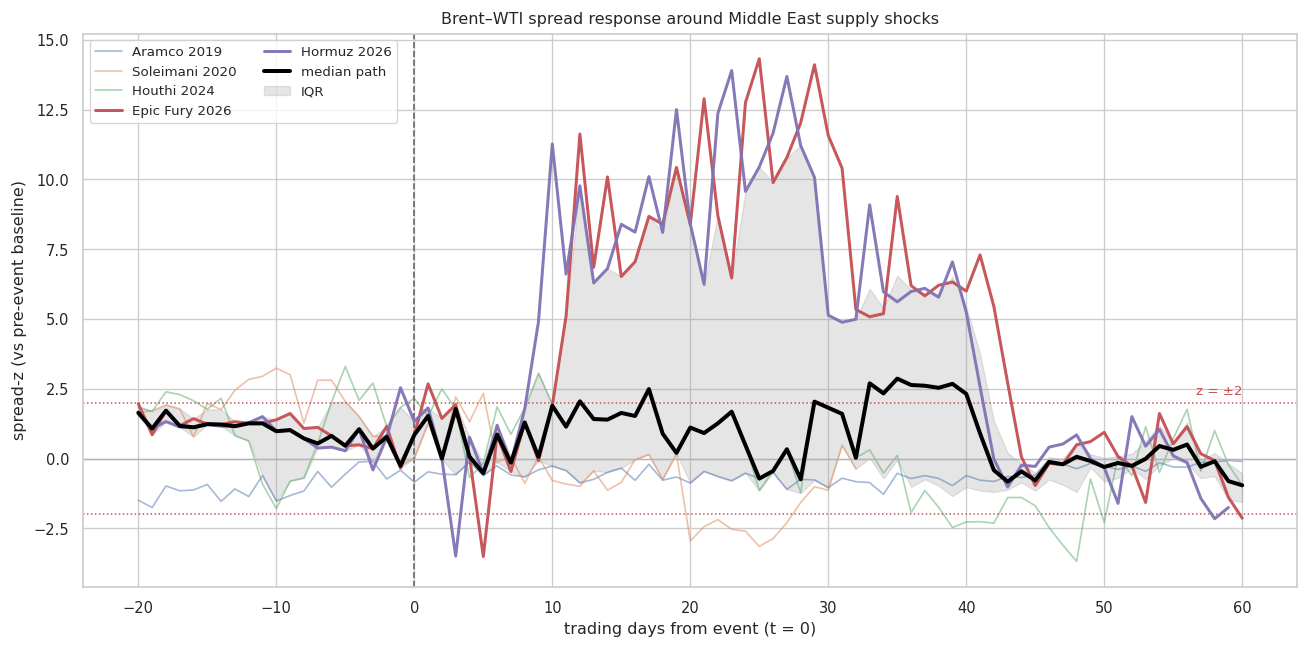

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# ── Per-event z-paths ────────────────────────────────────────────────────────
# 2026 events drawn bold/opaque to stand out; historicals drawn thin/faded.
for name in EVENTS:
    is_2026 = "2026" in name
    ax.plot(z_paths.index, z_paths[name],
            lw=1.8 if is_2026 else 1.0,
            alpha=0.95 if is_2026 else 0.5,
            label=name,
            zorder=3 if is_2026 else 2)

# ── Cross-event median + IQR band ────────────────────────────────────────────
# Median and IQR computed across all five events at each offset.
# NaN offsets (censored / truncated windows) are silently ignored by pandas.
# The band gives a visual sense of "typical" event behaviour.
median = z_paths.median(axis=1)
q25, q75 = z_paths.quantile(0.25, axis=1), z_paths.quantile(0.75, axis=1)
ax.plot(z_paths.index, median, color="black", lw=2.4, label="median path", zorder=4)
ax.fill_between(z_paths.index, q25, q75, color="0.6", alpha=0.25, label="IQR", zorder=1)

# ── Reference lines ──────────────────────────────────────────────────────────
ax.axvline(0, color="0.4", ls="--", lw=1)          # event day
ax.axhline(0, color="0.7", lw=0.8)                 # zero (baseline mean)
for lvl in (2, -2):                                # ±2σ significance threshold
    ax.axhline(lvl, color="C3", ls=":", lw=0.9)
ax.text(WIN_POST, 2.2, "z = ±2", color="C3", fontsize=8, ha="right", va="bottom")

ax.set_xlabel("trading days from event (t = 0)")
ax.set_ylabel("spread-z (vs pre-event baseline)")
ax.set_title("Brent–WTI spread response around Middle East supply shocks")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
# Save high-res version for the paper
fig.savefig(REPO / "figures" / "fig_money_plot.png", bbox_inches="tight")
plt.show()


## Headline event-study numbers

For the README table and the paper's event-study paragraph. The contrast between the historical comparables (muted, fast) and 2026 (large, sustained) is the short-vs-long-term spine of the thesis.

In [6]:
# Split events into historical comparables vs 2026 focal events.
# This split drives the paper's core contrast.
hist  = metrics.loc[["Aramco 2019", "Soleimani 2020", "Houthi 2024"]]
focal = metrics.loc[["Epic Fury 2026", "Hormuz 2026"]]

# Headline numbers for the README table and the event-study paragraph.
# Key story: historical peak |z| ≈ 3, 2026 ≈ 12; vol ratio 1.2× vs 8.3×.
summary = pd.Series({
    "Historical median peak |z|":          round(hist["peak |z|"].median(), 2),
    "Historical max peak |z|":             round(hist["peak |z|"].max(), 2),
    "2026 median peak z":                  round(focal["peak z (signed)"].median(), 2),
    "2026 median days-to-peak":            focal["days to peak"].median(),
    "Historical median vol ratio":         round(hist["vol ratio"].median(), 2),
    "2026 median vol ratio (post/pre)":    round(focal["vol ratio"].median(), 2),
})
summary.to_frame("value")


,value
Historical median peak |z|,2.95
Historical max peak |z|,3.06
2026 median peak z,12.07
2026 median days-to-peak,15.50
Historical median vol ratio,1.18
2026 median vol ratio (post/pre),8.48


## Establishing the shock — the 2026 dislocation in context

Before the formal event study, this figure establishes the raw shock: Brent and WTI price levels, the dollar spread, and 20-day realised volatility of the spread through the conflict. Vertical dashed lines mark Epic Fury (28 Feb 2026) and the Hormuz closure (4 Mar 2026).

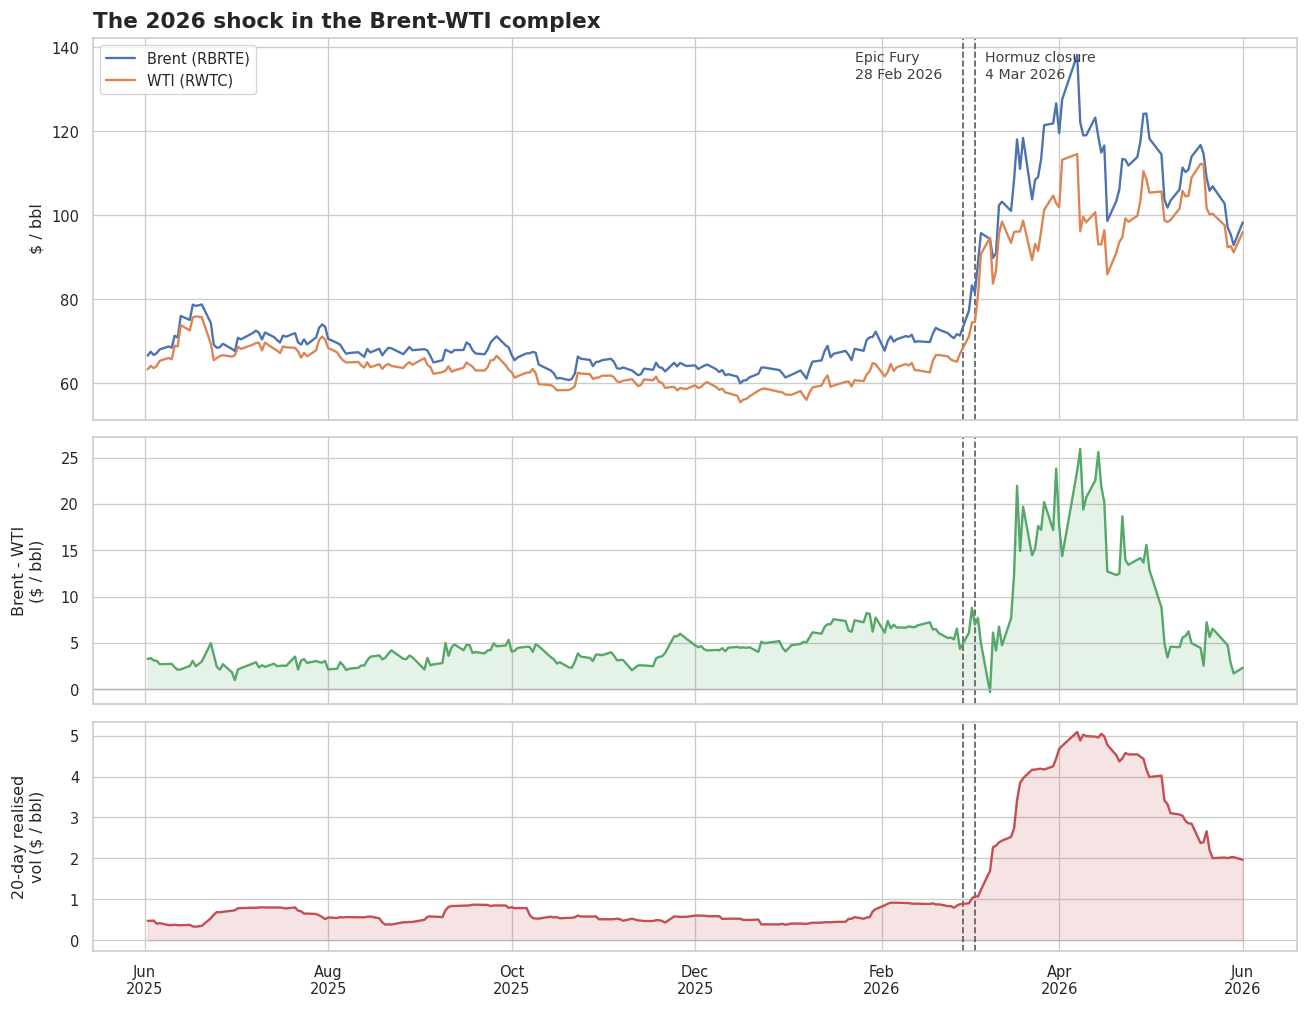

Peak |spread| in window: 25.94 $/bbl on 2026-04-08
Peak 20-day realised vol: 5.09 $/bbl vs Jan-2026 baseline 0.49


In [7]:
# ── Figure: establishing the 2026 shock ───────────────────────────────────────
# Three stacked panels over a mid-2025 -> data-edge window:
#   (1) Brent & WTI spot levels, (2) the dollar spread, (3) 20-day realised vol.
# Epic Fury (28 Feb) and Hormuz (4 Mar) annotated across all panels.
import matplotlib.dates as mdates

shock = df.copy()
shock["spread_chg"] = shock["spread"].diff()
shock["rv20"] = shock["spread_chg"].rolling(20).std()   # 20-day realised vol ($/bbl)
w = shock.loc["2025-06-01":]                             # context window through data edge

EPIC, HORMUZ = pd.Timestamp("2026-02-28"), pd.Timestamp("2026-03-04")

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(11, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [2, 1.4, 1.2]})

# Panel 1 — outright levels
ax1.plot(w.index, w["brent"], color="C0", lw=1.4, label="Brent (RBRTE)")
ax1.plot(w.index, w["wti"],   color="C1", lw=1.4, label="WTI (RWTC)")
ax1.set_ylabel("$ / bbl")
ax1.legend(loc="upper left", frameon=True)
ax1.set_title("The 2026 shock in the Brent-WTI complex",
              loc="left", fontsize=13, fontweight="bold")

# Panel 2 — dollar spread
ax2.plot(w.index, w["spread"], color="C2", lw=1.4)
ax2.axhline(0, color="0.7", lw=0.8)
ax2.fill_between(w.index, 0, w["spread"], color="C2", alpha=0.15)
ax2.set_ylabel("Brent - WTI\n($ / bbl)")

# Panel 3 — realised vol
ax3.plot(w.index, w["rv20"], color="C3", lw=1.4)
ax3.fill_between(w.index, 0, w["rv20"], color="C3", alpha=0.15)
ax3.set_ylabel("20-day realised\nvol ($ / bbl)")

# Event annotations
for ax in (ax1, ax2, ax3):
    for d in (EPIC, HORMUZ):
        ax.axvline(d, color="0.35", ls="--", lw=1.0, zorder=1)
ymax = ax1.get_ylim()[1]
ax1.annotate("Epic Fury\n28 Feb 2026", xy=(EPIC, ymax), xytext=(-65, -8),
             textcoords="offset points", fontsize=8.5, color="0.25", ha="left", va="top")
ax1.annotate("Hormuz closure\n4 Mar 2026", xy=(HORMUZ, ymax), xytext=(6, -8),
             textcoords="offset points", fontsize=8.5, color="0.25", ha="left", va="top")

ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.align_ylabels()
plt.tight_layout()
plt.savefig(REPO / "figures" / "fig_shock_2026.png", bbox_inches="tight")
plt.show()

print(f"Peak |spread| in window: {w['spread'].abs().max():.2f} $/bbl "
      f"on {w['spread'].abs().idxmax().date()}")
print(f"Peak 20-day realised vol: {w['rv20'].max():.2f} $/bbl "
      f"vs Jan-2026 baseline {shock.loc['2026-01','rv20'].mean():.2f}")
